# AlphaGenomeR: R Wrapper for Google DeepMind AlphaGenome API

This notebook demonstrates how to use the `AlphaGenomeR` package to predict multimodal genomic features using the AlphaGenome API. 

### Prerequisites
1. **Python SDK**: `pip install alphagenome`
2. **R Packages**: `reticulate`, `AlphaGenomeR` (local load for this demo)

In [1]:
# Load required libraries
library(reticulate)
devtools::load_all(".") # Load the local package

# Set your API Key
api_key <- "YOUR_API_KEY"

ℹ Loading AlphaGenomeR


## 1. Querying the API
AlphaGenome requires a 1MB genomic interval. We will query a region on Chromosome 17.

In [2]:
# Define region (hg38)
region <- "chr17:42560601-43609177"

# Query predictions for Lung tissue (UBERON:0002048)
predictions <- alphagenome_query(
  access_token = api_key,
  genomic_region = region,
  ontology_terms = c("UBERON:0002048"),
  requested_outputs = c("RNA_SEQ", "ATAC", "CAGE", "DNASE")
)

message("Available tracks in response: ", paste(names(predictions), collapse = ", "))

Available tracks in response: atac, cage, chip_histone, chip_tf, contact_maps, dnase, filter_ontology_terms, filter_output_type, filter_to_strand, get, map_track_data, procap, resize, rna_seq, splice_junctions, splice_site_usage, splice_sites 


## 2. Extracting Modalities
Use the helper functions to extract specific data types. Each function returns a list with `values` (numeric matrix) and `metadata`.

In [3]:
# Extract RNA-seq predictions
rna_seq <- alphagenome_get_rna_seq(predictions)
cat("RNA-seq matrix dimensions:", paste(dim(rna_seq$values), collapse=' x '), "\n")

# Extract ATAC-seq predictions
atac <- alphagenome_get_atac(predictions)
cat("ATAC-seq matrix dimensions:", paste(dim(atac$values), collapse=' x '), "\n")

RNA-seq matrix dimensions: 1048576 x 4 
ATAC-seq matrix dimensions: 1048576 x 1 


## 3. Visualization
We can plot the first track of the predicted ATAC-seq signal across the 1MB region.

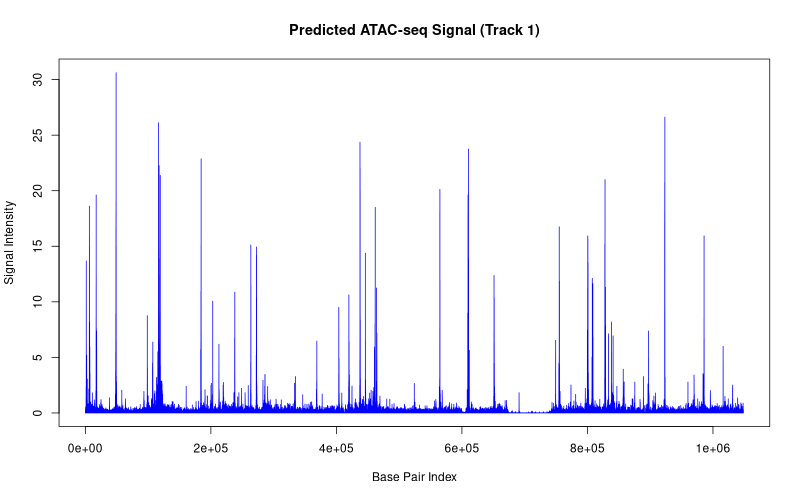

In [4]:
# Simple visualization of the first ATAC track
plot(atac$values[,1], type="l", col="blue", 
     main="Predicted ATAC-seq Signal (Track 1)", 
     xlab="Base Pair Index", ylab="Signal Intensity")

## 4. Full List of Supported Extractors
The package provides specialized extractors for all AlphaGenome modalities:

- `alphagenome_get_rna_seq()`
- `alphagenome_get_atac()`
- `alphagenome_get_cage()`
- `alphagenome_get_dnase()`
- `alphagenome_get_chip_histone()`
- `alphagenome_get_chip_tf()`
- `alphagenome_get_splice_sites()`
- `alphagenome_get_splice_junctions()`
- `alphagenome_get_splice_usage()`
- `alphagenome_get_procap()`
- `alphagenome_get_contact_maps()`